# 📈 Linear Regression Model for Next-Year Stock Return Prediction
---
**Objective:** Use firm-level financial data at year *t* to predict stock return at year *t+1*

**Dataset:** ~22,031 observations | ~5,000 tickers | 207 features | 2014–2018

> The dataset is **pre-labelled**: `Stock_Return` for a given year already represents
> the return of the *following* year. No shifting is required.

| Split | Years | Description |
|-------|-------|-------------|
| Train | 2014–2017 | Financial indicators → paired next-year returns (2015–2018) |
| Test  | 2018      | Financial indicators → paired 2019 returns |

**Models:** Linear Regression · Ridge · Lasso · Elastic Net · PCA + Ridge

## Cell 0 — Import Libraries

In [1]:
print("hello")

hello


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, pearsonr

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False



---
## Step 1 — Load & Combine Datasets

In [3]:
df = pd.read_csv("cleaned_dataset.csv")  

In [4]:
# Sanity check: Stock_Return is already the pre-labelled target
print("Sample of key columns:")
df[["Ticker", "Year", "Sector", "Stock_Return", "Class", "Return_Direction"]].head(10)

Sample of key columns:


,Ticker,Year,Sector,Stock_Return,Class,Return_Direction
0,PG,2014,Consumer Defensive,-9.3233,0,0
1,VIPS,2014,Consumer Defensive,-25.5122,0,0
2,KR,2014,Consumer Defensive,33.1183,1,1
3,RAD,2014,Consumer Defensive,2.7523,1,1
4,GIS,2014,Consumer Defensive,12.8977,1,1
5,PM,2014,Consumer Defensive,13.9809,1,1
6,KO,2014,Consumer Defensive,5.3394,1,1
7,WMT,2014,Consumer Defensive,-26.6537,0,0
8,MDLZ,2014,Consumer Defensive,23.8098,1,1
9,MO,2014,Consumer Defensive,23.8655,1,1


---
## Step 2 — Sort & Inspect the Pre-Labelled Target

`Stock_Return` is already paired with the correct forward return — **no shifting needed**.
`Class` and `Return_Direction` are derived from `Stock_Return` and must be treated as leakage.

In [5]:
df = df.sort_values(["Ticker", "Year"]).reset_index(drop=True)

TARGET_COL = "Stock_Return"

print("Target variable: Stock_Return")
print("=" * 40)
print(df[TARGET_COL].describe().to_string())

Target variable: Stock_Return
count   22031.0000
mean        7.6649
std        52.6213
min       -99.9994
25%       -19.5299
50%         3.8351
75%        27.3304
max       975.6097


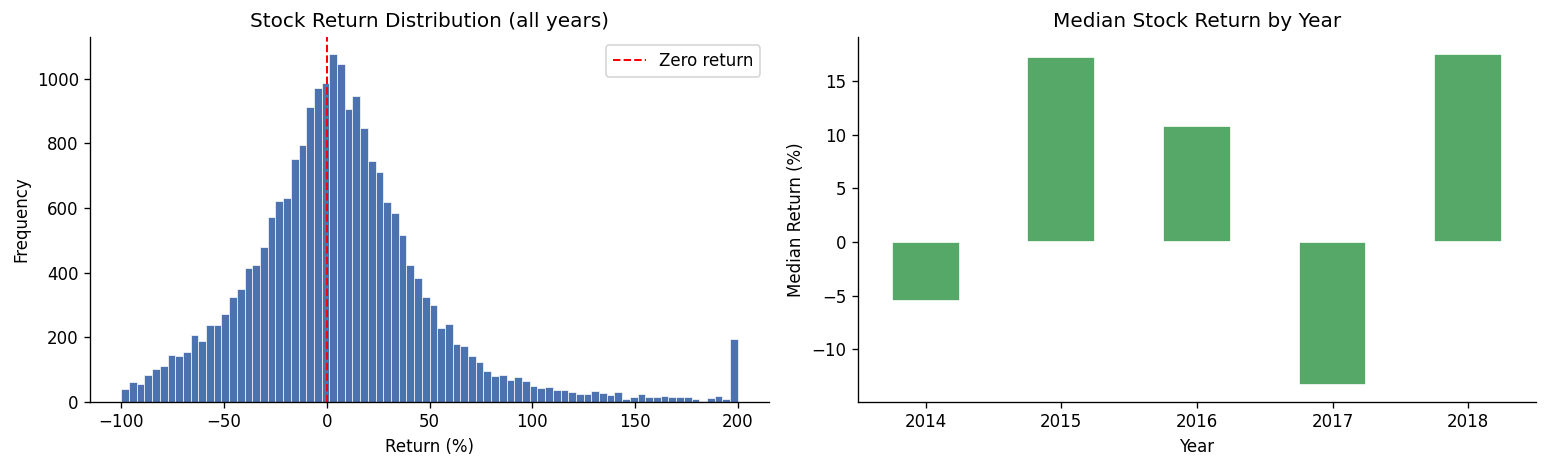

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET_COL].clip(-100, 200), bins=80,
             color="#4C72B0", edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero return")
axes[0].set_title("Stock Return Distribution (all years)")
axes[0].set_xlabel("Return (%)"); axes[0].set_ylabel("Frequency")
axes[0].legend()

df.groupby("Year")[TARGET_COL].median().plot(
    kind="bar", ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Median Stock Return by Year")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Median Return (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("01_target_distribution.png", bbox_inches="tight")
plt.show()

---
## Step 3 — Define Features & Remove Leakage Variables

Exclude:
- `Stock_Return` — **this is the target**
- `Class` — derived from Stock_Return (direction label)
- `Return_Direction` — derived from Stock_Return (binary label)
- `Ticker`, `Year` — identifiers, not predictors

In [7]:
LEAKAGE_COLS     = ["Class", "Return_Direction"]
ID_COLS          = ["Ticker", "Year"]
TARGET_COL       = "Stock_Return"
CATEGORICAL      = ["Sector"]

exclude          = LEAKAGE_COLS + ID_COLS + [TARGET_COL] + CATEGORICAL
NUMERIC_FEATURES = [c for c in df.columns
                    if c not in exclude
                    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

print(f"Numeric features available : {len(NUMERIC_FEATURES)}")
print(f"Categorical features       : {CATEGORICAL}")
print(f"Leakage columns excluded   : {LEAKAGE_COLS}")

# Missing value overview
miss = df[NUMERIC_FEATURES].isnull().mean().sort_values(ascending=False)
print(f"\nMissing value summary:")
print(f"  Features with >50% missing : {(miss > 0.50).sum()}")
print(f"  Features with >20% missing : {(miss > 0.20).sum()}")
print(f"  Features with  >5% missing : {(miss > 0.05).sum()}")
print(f"  Features with   0% missing : {(miss == 0.00).sum()}")

Numeric features available : 201
Categorical features       : ['Sector']
Leakage columns excluded   : ['Class', 'Return_Direction']

Missing value summary:
  Features with >50% missing : 0
  Features with >20% missing : 0
  Features with  >5% missing : 0
  Features with   0% missing : 201


---
## Step 4 — Time-Based Train / Test Split

| Split | Years | Rows |
|-------|-------|------|
| **Train** | 2014, 2015, 2016, 2017 | ~17,641 |
| **Test**  | 2018                   | ~4,390  |

A time-series split prevents any look-ahead bias.
Expanding-window cross-validation is used within the training period for hyper-parameter tuning.

In [8]:
TRAIN_YEARS = [2014, 2015, 2016, 2017]
TEST_YEAR   = 2018

train_df = df[df["Year"].isin(TRAIN_YEARS)].copy()
test_df  = df[df["Year"] == TEST_YEAR].copy()

print("Time-Based Split")
print("=" * 40)
print(f"  Train (2014–2017) : {len(train_df):>6,} rows")
print(f"  Test  (2018)      : {len(test_df):>6,} rows")
print(f"  Total             : {len(train_df) + len(test_df):>6,} rows")
print()
print("Training set — rows per year:")
print(train_df["Year"].value_counts().sort_index().to_string())

X_train = train_df[NUMERIC_FEATURES + CATEGORICAL]
y_train = train_df[TARGET_COL]

X_test  = test_df[NUMERIC_FEATURES + CATEGORICAL]
y_test  = test_df[TARGET_COL]

Time-Based Split
  Train (2014–2017) : 17,641 rows
  Test  (2018)      :  4,390 rows
  Total             : 22,031 rows

Training set — rows per year:
Year
2014    3787
2015    4114
2016    4783
2017    4957


---
## Step 5 — Feature Engineering

| Transform | Purpose |
|-----------|---------|
| **Winsorisation** (1–99th pct) | Clip heavy-tailed outliers common in financial data |
| **Signed-log** | Compress size variables (Revenue, Assets, Market Cap) |
| **Cross-sectional z-score** | Remove year-level scale differences |
| **Sector-relative** | Remove sector-wide systematic effects |
| **Δ features** | Capture YoY changes in key ratios |

All parameters are **fit on the training set only** to avoid leakage.

In [10]:
# ── 5.1  Winsorisation ────────────────────────────────────────────────────────
print("5.1  Winsorisation (1st–99th percentile) ...")
winsor_bounds = {}
X_train_w     = train_df[NUMERIC_FEATURES].copy()

for col in NUMERIC_FEATURES:
    lo = X_train_w[col].quantile(0.01)
    hi = X_train_w[col].quantile(0.99)
    winsor_bounds[col] = (lo, hi)
    X_train_w[col] = X_train_w[col].clip(lo, hi)

X_test_w = test_df[NUMERIC_FEATURES].copy()
for col, (lo, hi) in winsor_bounds.items():
    X_test_w[col] = X_test_w[col].clip(lo, hi)



5.1  Winsorisation (1st–99th percentile) ...


In [12]:
# ── 5.2  Signed-log on size variables ─────────────────────────────────────────
print("5.2  Signed-log: sign(x) * log(1 + |x|) ...")
SIZE_VARS = [c for c in ["Revenue", "Total assets", "Market Cap", "Enterprise Value"]
             if c in NUMERIC_FEATURES]

def signed_log(series):
    return np.sign(series) * np.log1p(np.abs(series))

for col in SIZE_VARS:
    X_train_w[col] = signed_log(X_train_w[col])
    X_test_w[col]  = signed_log(X_test_w[col])

print(f"     Applied to: {SIZE_VARS}")


5.2  Signed-log: sign(x) * log(1 + |x|) ...
     Applied to: ['Revenue', 'Total assets', 'Market Cap', 'Enterprise Value']


In [13]:
# ── 5.3  Cross-sectional z-score (fit on train, per year) ─────────────────────
print("5.3  Cross-sectional z-score standardisation ...")

year_stats = {}
for yr in TRAIN_YEARS:
    mask = (train_df["Year"] == yr)
    year_stats[yr] = {
        "mean": X_train_w[mask].mean(),
        "std":  X_train_w[mask].std().replace(0, 1),
    }

def cs_standardise(X_feat, year_series, stats, fallback=2017):
    out = X_feat.copy()
    for yr in year_series.unique():
        ref  = yr if yr in stats else fallback
        mask = (year_series == yr)
        out.loc[mask] = (X_feat.loc[mask] - stats[ref]["mean"]) / stats[ref]["std"]
    return out

X_train_cs = cs_standardise(X_train_w, train_df["Year"], year_stats)
X_test_cs  = cs_standardise(X_test_w,  test_df["Year"],  year_stats, fallback=2017)
print("Done")

5.3  Cross-sectional z-score standardisation ...
Done


In [14]:
# ── 5.4  Sector-relative features (subtract sector median, fit on train) ───────
print("5.4  Sector-relative adjustment ...")

sector_medians  = {}
for sec in train_df["Sector"].unique():
    mask = (train_df["Sector"] == sec)
    sector_medians[sec] = X_train_cs[mask].median()

fallback_sec = train_df["Sector"].mode()[0]

def sector_adjust(X_feat, sector_series, medians, fallback):
    out = X_feat.copy()
    for sec in sector_series.unique():
        med  = medians.get(sec, medians[fallback])
        mask = (sector_series == sec)
        out.loc[mask] = X_feat.loc[mask] - med
    return out

X_train_sa = sector_adjust(X_train_cs, train_df["Sector"], sector_medians, fallback_sec)
X_test_sa  = sector_adjust(X_test_cs,  test_df["Sector"],  sector_medians, fallback_sec)
print("Done")

5.4  Sector-relative adjustment ...
Done


In [15]:
# ── 5.5  Lag-based Δ features (YoY change in key ratios) ──────────────────────
print("5.5  Delta features (ΔROE, ΔDebt/Equity, ΔNet Profit Margin, ΔRevenue Growth) ...")

DELTA_PAIRS = {
    "delta_Net_Profit_Margin" : "Net Profit Margin",
    "delta_ROE"               : "ROE",
    "delta_Debt_to_Equity"    : "Debt to Equity",
    "delta_Revenue_Growth"    : "Revenue Growth",
}

# Use original df (sorted) so diff() spans across the full panel
for new_col, src_col in DELTA_PAIRS.items():
    col = src_col if src_col in df.columns else None
    if col:
        df[new_col] = df.groupby("Ticker")[col].diff()

DELTA_COLS  = [c for c in DELTA_PAIRS.keys() if c in df.columns]
delta_train = df[df["Year"].isin(TRAIN_YEARS)][DELTA_COLS].reset_index(drop=True)
delta_test  = df[df["Year"] == TEST_YEAR][DELTA_COLS].reset_index(drop=True)

X_train_eng = pd.concat([X_train_sa.reset_index(drop=True), delta_train], axis=1)
X_test_eng  = pd.concat([X_test_sa.reset_index(drop=True),  delta_test],  axis=1)

X_train_eng["Sector"] = train_df["Sector"].values
X_test_eng["Sector"]  = test_df["Sector"].values

NUM_FEATS_ENG = NUMERIC_FEATURES + DELTA_COLS

print(f"\n Feature engineering complete.")
print(f"   Numeric features : {len(NUMERIC_FEATURES)} original + {len(DELTA_COLS)} delta = {len(NUM_FEATS_ENG)}")

5.5  Delta features (ΔROE, ΔDebt/Equity, ΔNet Profit Margin, ΔRevenue Growth) ...

 Feature engineering complete.
   Numeric features : 201 original + 4 delta = 205


---
## Step 6 — Feature Selection

Three sequential filters applied to the training set:

1. **Variance filter** — drop near-constant columns (threshold = 0.01)
2. **Correlation filter** — remove one from any highly-correlated pair (|r| > 0.92)
3. **Univariate selection** — keep top 60 by |Pearson r| with target

In [16]:
# ── 6.1  Variance filter ──────────────────────────────────────────────────────
print("6.1  Variance filter (threshold = 0.01) ...")
_imp   = SimpleImputer(strategy="median")
X_chk  = pd.DataFrame(_imp.fit_transform(X_train_eng[NUM_FEATS_ENG]), columns=NUM_FEATS_ENG)

vt     = VarianceThreshold(threshold=0.01)
vt.fit(X_chk)
high_var_feats = [f for f, keep in zip(NUM_FEATS_ENG, vt.get_support()) if keep]
print(f"     Dropped : {len(NUM_FEATS_ENG) - len(high_var_feats):>4}  |  Remaining : {len(high_var_feats)}")

6.1  Variance filter (threshold = 0.01) ...
     Dropped :    1  |  Remaining : 204


In [17]:
# ── 6.2  Correlation filter ───────────────────────────────────────────────────
print("6.2  Correlation filter (|r| > 0.92) ...")
X_hv   = X_chk[high_var_feats]
upper  = X_hv.corr().abs().where(
    np.triu(np.ones((len(high_var_feats), len(high_var_feats))), k=1).astype(bool))
drop_c = [c for c in upper.columns if any(upper[c] > 0.92)]
selected_feats = [f for f in high_var_feats if f not in drop_c]
print(f"     Dropped : {len(drop_c):>4}  |  Remaining : {len(selected_feats)}")

6.2  Correlation filter (|r| > 0.92) ...
     Dropped :   52  |  Remaining : 152


In [18]:
# ── 6.3  Univariate selection — top 60 by |Pearson r| with target ─────────────
print("6.3  Univariate selection — top 60 by |Pearson r| ...")
X_imp    = X_hv[selected_feats].fillna(X_hv[selected_feats].median())
y_arr    = y_train.values

corr_map = {col: abs(pearsonr(X_imp[col].values, y_arr)[0]) for col in selected_feats}
corr_ser = pd.Series(corr_map).sort_values(ascending=False)

FINAL_NUM_FEATS = corr_ser.head(60).index.tolist()
CAT_FEATS       = ["Sector"]

print(f"\n   Top 15 predictors by |Pearson r|:")
print(corr_ser.head(15).to_string())

6.3  Univariate selection — top 60 by |Pearson r| ...

   Top 15 predictors by |Pearson r|:
EPS                                      0.1345
freeCashFlowPerShare                     0.0976
Book Value per Share                     0.0728
priceToSalesRatio                        0.0683
EBITDA Margin                            0.0676
returnOnCapitalEmployed                  0.0642
Weighted Average Shares Growth           0.0639
EBIT Margin                              0.0615
Weighted Average Shares Diluted Growth   0.0591
EV to Sales                              0.0573
priceSalesRatio                          0.0567
SG&A Expenses Growth                     0.0549
Asset Growth                             0.0493
Tangible Book Value per Share            0.0484
daysOfPayablesOutstanding                0.0476


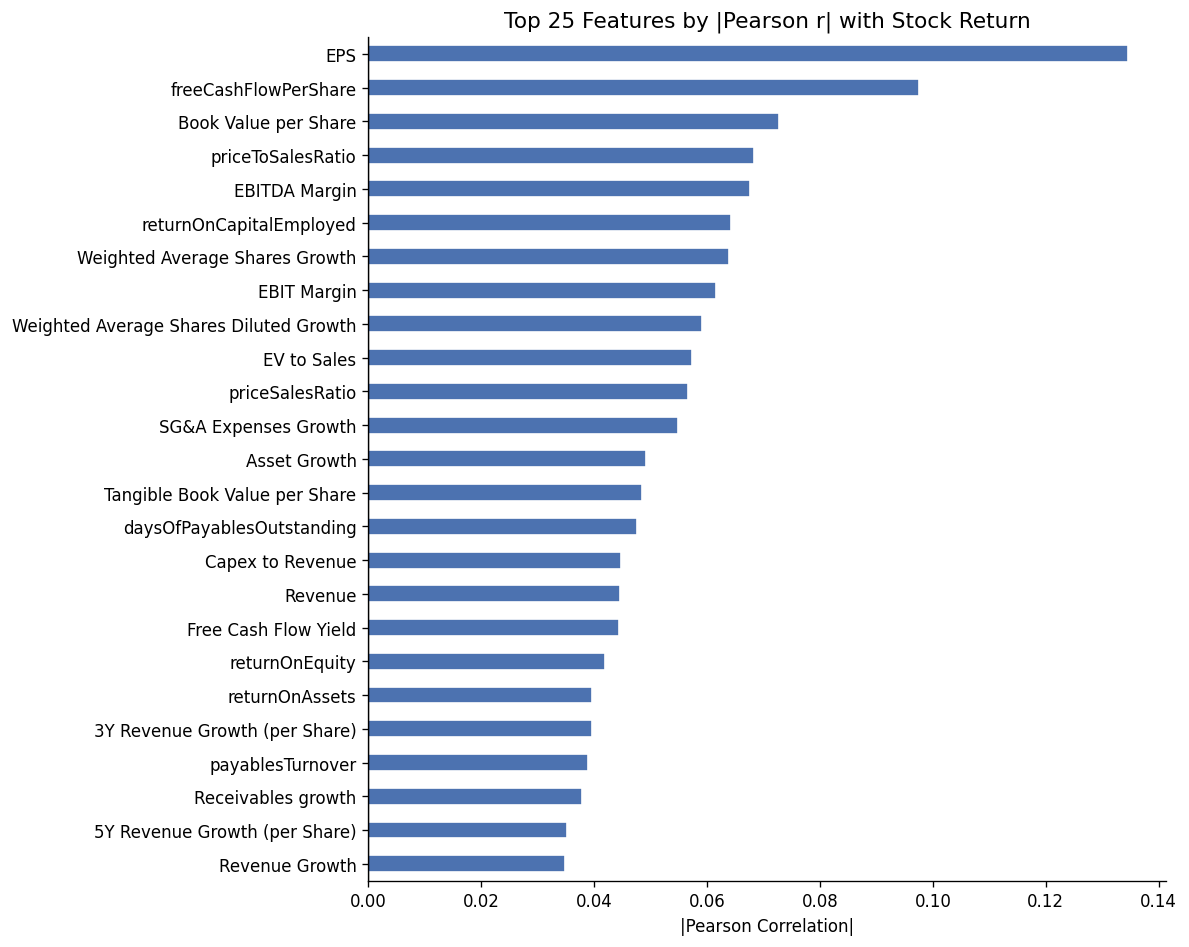

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_ser.head(25).sort_values().plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Top 25 Features by |Pearson r| with Stock Return", fontsize=13)
ax.set_xlabel("|Pearson Correlation|")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("02_feature_importances.png", bbox_inches="tight")
plt.show()

---
## Step 7 — Preprocessing Pipeline
Scikit-learn `ColumnTransformer` combining:
- **Numeric:** median imputation → StandardScaler
- **Categorical:** most-frequent imputation → OneHotEncoder

In [20]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     FINAL_NUM_FEATS),
    ("cat", categorical_transformer, CAT_FEATS),
])

print(f"Numeric features in pipeline  : {len(FINAL_NUM_FEATS)}")
print(f"Categorical features          : {CAT_FEATS}")
print("Preprocessor ready.")

Numeric features in pipeline  : 60
Categorical features          : ['Sector']
Preprocessor ready.


---
## Step 8 — Evaluation & Portfolio Metric Helpers

In [21]:
def evaluate(y_true, y_pred, label=""):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    pr,  _ = pearsonr(y_true,  y_pred)
    sr,  _ = spearmanr(y_true, y_pred)
    res  = dict(MSE=mse, RMSE=rmse, MAE=mae, R2=r2, Pearson_r=pr, Spearman_IC=sr)
    if label:
        print(f"\n{'='*52}\n  {label}\n{'='*52}")
        for k, v in res.items():
            print(f"  {k:<18} {v:>10.4f}")
    return res

def top_decile_return(y_true, y_pred, q=0.9):
    thr = np.quantile(y_pred, q)
    return np.asarray(y_true)[np.asarray(y_pred) >= thr].mean()

def long_short_spread(y_true, y_pred, q=0.1):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    top = y_true[y_pred >= np.quantile(y_pred, 1 - q)].mean()
    bot = y_true[y_pred <= np.quantile(y_pred,     q)].mean()
    return top - bot



---
## Step 9 — Expanding-Window Cross-Validation Helper

Used for hyper-parameter tuning within the training period (2014–2017).

| Fold | Train | Validate |
|------|-------|----------|
| 1 | 2014 | 2015 |
| 2 | 2014–2015 | 2016 |
| 3 | 2014–2016 | 2017 |

In [22]:
CV_SPLITS = [
    ([2014],             2015),
    ([2014, 2015],       2016),
    ([2014, 2015, 2016], 2017),
]

def expanding_cv(pipeline, df_src, cv_splits, num_feats, cat_feats, target=TARGET_COL):
    records = []
    for train_yrs, val_yr in cv_splits:
        tr = df_src[df_src["Year"].isin(train_yrs)]
        va = df_src[df_src["Year"] == val_yr]

        # Rebuild engineered X from the pre-computed eng frames
        tr_idx = train_df.index[train_df["Year"].isin(train_yrs)]
        va_idx = train_df.index[train_df["Year"] == val_yr]

        X_tr = X_train_eng.loc[tr_idx, num_feats + cat_feats]
        y_tr = y_train.loc[tr_idx]
        X_va = X_train_eng.loc[va_idx, num_feats + cat_feats]
        y_va = y_train.loc[va_idx]

        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict(X_va)

        rmse = np.sqrt(mean_squared_error(y_va, preds))
        r2   = r2_score(y_va, preds)
        ic,_ = spearmanr(y_va, preds)
        ls   = long_short_spread(y_va.values, preds)

        records.append(dict(Train=str(train_yrs), Val_Year=val_yr,
                            RMSE=rmse, R2=r2, Spearman_IC=ic, LS_Spread=ls))
        print(f"  Train {train_yrs} → Val {val_yr} | "
              f"RMSE={rmse:.2f}  R²={r2:.4f}  IC={ic:.4f}  L/S={ls:.2f}%")
    return pd.DataFrame(records)

# Reset index on train_df so .loc works cleanly
train_df = train_df.reset_index(drop=True)
X_train_eng = X_train_eng.reset_index(drop=True)
y_train     = y_train.reset_index(drop=True)



---
## Step 10 — Experiment 1: Baseline Linear Regression
Plain OLS with all 60 selected features — no regularisation.

In [23]:
print("=" * 60)
print("EXPERIMENT 1 — Baseline Linear Regression")
print("=" * 60)

pipe_lr = Pipeline([
    ("prep",  preprocessor),
    ("model", LinearRegression()),
])

print("\nExpanding-window CV:")
cv_lr = expanding_cv(pipe_lr, train_df, CV_SPLITS, FINAL_NUM_FEATS, CAT_FEATS)

# Final fit on full training set, evaluate on test
pipe_lr.fit(X_train_eng[FINAL_NUM_FEATS + CAT_FEATS], y_train)
pred_lr_test = pipe_lr.predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS])

res_lr = evaluate(y_test.values, pred_lr_test, "Linear Regression → Test 2018")

EXPERIMENT 1 — Baseline Linear Regression

Expanding-window CV:
  Train [2014] → Val 2015 | RMSE=62.59  R²=-0.3334  IC=-0.0322  L/S=-9.38%
  Train [2014, 2015] → Val 2016 | RMSE=56.56  R²=-0.0490  IC=0.0526  L/S=13.74%
  Train [2014, 2015, 2016] → Val 2017 | RMSE=47.56  R²=-0.3560  IC=0.1296  L/S=21.05%

  Linear Regression → Test 2018
  MSE                 3459.7345
  RMSE                  58.8195
  MAE                   37.1202
  R2                    -0.0538
  Pearson_r              0.0865
  Spearman_IC            0.0823


---
## Step 11 — Experiment 2: Ridge / Lasso / Elastic Net
Alpha grid-search using expanding-window CV; best alpha chosen by Spearman IC.

In [25]:
print("=" * 60)
print("EXPERIMENT 2 — Ridge / Lasso / Elastic Net")
print("=" * 60)

ALPHAS = [0.01, 0.1, 1, 10, 50, 100, 500]
results_reg = []
best_pipes  = {}

for ModelClass, name in [(Ridge, "Ridge"), (Lasso, "Lasso"), (ElasticNet, "ElasticNet")]:
    print(f"\n── {name} ──")
    best_ic, best_alpha, best_pipe = -np.inf, None, None

    for alpha in ALPHAS:
        kw = {"alpha": alpha, "max_iter": 5000}
        if ModelClass is ElasticNet:
            kw["l1_ratio"] = 0.5

        pipe = Pipeline([("prep", preprocessor), ("model", ModelClass(**kw))])
        # CV over training folds
        fold_ics = []
        for train_yrs, val_yr in CV_SPLITS:
            tr_idx = train_df.index[train_df["Year"].isin(train_yrs)]
            va_idx = train_df.index[train_df["Year"] == val_yr]
            pipe.fit(X_train_eng.loc[tr_idx, FINAL_NUM_FEATS + CAT_FEATS], y_train.loc[tr_idx])
            p  = pipe.predict(X_train_eng.loc[va_idx, FINAL_NUM_FEATS + CAT_FEATS])
            ic, _ = spearmanr(y_train.loc[va_idx], p)
            fold_ics.append(ic)
        mean_ic = np.mean(fold_ics)
        if mean_ic > best_ic:
            best_ic, best_alpha = mean_ic, alpha

    # Refit best on full training set
    kw = {"alpha": best_alpha, "max_iter": 5000}
    if ModelClass is ElasticNet: kw["l1_ratio"] = 0.5
    best_pipe = Pipeline([("prep", preprocessor), ("model", ModelClass(**kw))])
    best_pipe.fit(X_train_eng[FINAL_NUM_FEATS + CAT_FEATS], y_train)
    best_pipes[name] = best_pipe

    preds_test = best_pipe.predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS])
    m = evaluate(y_test.values, preds_test, f"{name} (alpha={best_alpha}) → Test 2018")
    results_reg.append({"Model": name, "Best_Alpha": best_alpha, **{f"Test_{k}": v for k, v in m.items()}})

reg_df = pd.DataFrame(results_reg)
print("\n\nRegularisation Summary (Test 2018):")
reg_df[["Model", "Best_Alpha", "Test_R2", "Test_RMSE", "Test_Spearman_IC"]]

EXPERIMENT 2 — Ridge / Lasso / Elastic Net

── Ridge ──

  Ridge (alpha=500) → Test 2018
  MSE                 3456.5724
  RMSE                  58.7926
  MAE                   37.0898
  R2                    -0.0529
  Pearson_r              0.0825
  Spearman_IC            0.0730

── Lasso ──

  Lasso (alpha=1) → Test 2018
  MSE                 3461.3046
  RMSE                  58.8329
  MAE                   37.0956
  R2                    -0.0543
  Pearson_r              0.0798
  Spearman_IC            0.0519

── ElasticNet ──

  ElasticNet (alpha=10) → Test 2018
  MSE                 3502.6536
  RMSE                  59.1832
  MAE                   37.5064
  R2                    -0.0669
  Pearson_r              0.1407
  Spearman_IC            0.1999


Regularisation Summary (Test 2018):


,Model,Best_Alpha,Test_R2,Test_RMSE,Test_Spearman_IC
0,Ridge,500,-0.0529,58.7926,0.0730
1,Lasso,1,-0.0543,58.8329,0.0519
2,ElasticNet,10,-0.0669,59.1832,0.1999


---
## Step 12 — Experiment 3: Correlation-Filtered Feature Set
Use the larger post-correlation-filter set (before univariate top-60) with Ridge.

In [26]:
print("=" * 60)
print("EXPERIMENT 3 — Ridge on Correlation-Filtered Features")
print("=" * 60)

CORR_FILTER_FEATS = [f for f in selected_feats if f in NUM_FEATS_ENG]

prep_cf = ColumnTransformer([
    ("num", numeric_transformer,     CORR_FILTER_FEATS),
    ("cat", categorical_transformer, CAT_FEATS),
])

best_ic, best_alpha_cf, best_pipe_cf = -np.inf, None, None
for alpha in ALPHAS:
    pipe = Pipeline([("prep", prep_cf), ("model", Ridge(alpha=alpha))])
    fold_ics = []
    for train_yrs, val_yr in CV_SPLITS:
        tr_idx = train_df.index[train_df["Year"].isin(train_yrs)]
        va_idx = train_df.index[train_df["Year"] == val_yr]
        pipe.fit(X_train_eng.loc[tr_idx, CORR_FILTER_FEATS + CAT_FEATS], y_train.loc[tr_idx])
        p = pipe.predict(X_train_eng.loc[va_idx, CORR_FILTER_FEATS + CAT_FEATS])
        ic, _ = spearmanr(y_train.loc[va_idx], p)
        fold_ics.append(ic)
    if np.mean(fold_ics) > best_ic:
        best_ic, best_alpha_cf = np.mean(fold_ics), alpha

best_pipe_cf = Pipeline([("prep", prep_cf), ("model", Ridge(alpha=best_alpha_cf))])
best_pipe_cf.fit(X_train_eng[CORR_FILTER_FEATS + CAT_FEATS], y_train)
preds_cf_test = best_pipe_cf.predict(X_test_eng[CORR_FILTER_FEATS + CAT_FEATS])

_ = evaluate(y_test.values, preds_cf_test,
             f"Ridge + Corr-Filter (alpha={best_alpha_cf}) → Test 2018")

EXPERIMENT 3 — Ridge on Correlation-Filtered Features

  Ridge + Corr-Filter (alpha=500) → Test 2018
  MSE                 3466.4583
  RMSE                  58.8766
  MAE                   37.3324
  R2                    -0.0559
  Pearson_r              0.0801
  Spearman_IC            0.0576


---
## Step 13 — Experiment 4: Lasso-Selected Features → Ridge
Lasso's non-zero coefficients act as a feature mask; Ridge is then fit on that subset.

In [27]:
print("=" * 60)
print("EXPERIMENT 4 — Lasso Feature Selection → Ridge")
print("=" * 60)

_prep_ls = ColumnTransformer([
    ("num", numeric_transformer,     FINAL_NUM_FEATS),
    ("cat", categorical_transformer, CAT_FEATS),
])
lasso_sel = Pipeline([("prep", _prep_ls), ("lasso", Lasso(alpha=0.01, max_iter=10000))])
lasso_sel.fit(X_train_eng[FINAL_NUM_FEATS + CAT_FEATS], y_train)

coef      = lasso_sel.named_steps["lasso"].coef_
ohe_names = (_prep_ls.named_transformers_["cat"]["onehot"]
             .get_feature_names_out(CAT_FEATS).tolist())
all_names = FINAL_NUM_FEATS + ohe_names
lasso_num_feats = [all_names[i] for i, c in enumerate(coef) if c != 0 and all_names[i] in FINAL_NUM_FEATS]

if not lasso_num_feats:
    lasso_num_feats = FINAL_NUM_FEATS
    print("Lasso zeroed all coefficients — using full feature set as fallback")

print(f"Non-zero Lasso coefficients : {sum(coef != 0)} / {len(coef)}")
print(f"Numeric features retained   : {len(lasso_num_feats)}")

prep_ls = ColumnTransformer([
    ("num", numeric_transformer,     lasso_num_feats),
    ("cat", categorical_transformer, CAT_FEATS),
])
best_ic, best_alpha_ls, best_pipe_ls = -np.inf, None, None
for alpha in ALPHAS:
    pipe = Pipeline([("prep", prep_ls), ("model", Ridge(alpha=alpha))])
    fold_ics = []
    for train_yrs, val_yr in CV_SPLITS:
        tr_idx = train_df.index[train_df["Year"].isin(train_yrs)]
        va_idx = train_df.index[train_df["Year"] == val_yr]
        pipe.fit(X_train_eng.loc[tr_idx, lasso_num_feats + CAT_FEATS], y_train.loc[tr_idx])
        p = pipe.predict(X_train_eng.loc[va_idx, lasso_num_feats + CAT_FEATS])
        ic, _ = spearmanr(y_train.loc[va_idx], p)
        fold_ics.append(ic)
    if np.mean(fold_ics) > best_ic:
        best_ic, best_alpha_ls = np.mean(fold_ics), alpha

best_pipe_ls = Pipeline([("prep", prep_ls), ("model", Ridge(alpha=best_alpha_ls))])
best_pipe_ls.fit(X_train_eng[lasso_num_feats + CAT_FEATS], y_train)
preds_ls_test = best_pipe_ls.predict(X_test_eng[lasso_num_feats + CAT_FEATS])

_ = evaluate(y_test.values, preds_ls_test,
             f"Lasso-Select + Ridge (alpha={best_alpha_ls}) → Test 2018")

EXPERIMENT 4 — Lasso Feature Selection → Ridge
Non-zero Lasso coefficients : 68 / 71
Numeric features retained   : 58

  Lasso-Select + Ridge (alpha=500) → Test 2018
  MSE                 3456.5106
  RMSE                  58.7921
  MAE                   37.0896
  R2                    -0.0529
  Pearson_r              0.0826
  Spearman_IC            0.0730


---
## Step 14 — Experiment 5: PCA + Ridge
Reduce to 95% of explained variance, then fit Ridge.

In [28]:
print("=" * 60)
print("EXPERIMENT 5 — PCA + Ridge")
print("=" * 60)

prep_pca = ColumnTransformer([
    ("num", numeric_transformer,     FINAL_NUM_FEATS),
    ("cat", categorical_transformer, CAT_FEATS),
])

best_ic, best_alpha_pca, best_pipe_pca = -np.inf, None, None
for alpha in ALPHAS:
    pipe = Pipeline([
        ("prep",  prep_pca),
        ("pca",   PCA(n_components=0.95, random_state=42)),
        ("model", Ridge(alpha=alpha)),
    ])
    fold_ics = []
    for train_yrs, val_yr in CV_SPLITS:
        tr_idx = train_df.index[train_df["Year"].isin(train_yrs)]
        va_idx = train_df.index[train_df["Year"] == val_yr]
        pipe.fit(X_train_eng.loc[tr_idx, FINAL_NUM_FEATS + CAT_FEATS], y_train.loc[tr_idx])
        p = pipe.predict(X_train_eng.loc[va_idx, FINAL_NUM_FEATS + CAT_FEATS])
        ic, _ = spearmanr(y_train.loc[va_idx], p)
        fold_ics.append(ic)
    if np.mean(fold_ics) > best_ic:
        best_ic, best_alpha_pca = np.mean(fold_ics), alpha

best_pipe_pca = Pipeline([
    ("prep",  prep_pca),
    ("pca",   PCA(n_components=0.95, random_state=42)),
    ("model", Ridge(alpha=best_alpha_pca)),
])
best_pipe_pca.fit(X_train_eng[FINAL_NUM_FEATS + CAT_FEATS], y_train)
n_pc          = best_pipe_pca.named_steps["pca"].n_components_
preds_pca_test = best_pipe_pca.predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS])

print(f"PCA retained {n_pc} components at 95% variance")
_ = evaluate(y_test.values, preds_pca_test,
             f"PCA (n={n_pc}) + Ridge (alpha={best_alpha_pca}) → Test 2018")

EXPERIMENT 5 — PCA + Ridge
PCA retained 47 components at 95% variance

  PCA (n=47) + Ridge (alpha=500) → Test 2018
  MSE                 3457.5391
  RMSE                  58.8008
  MAE                   37.0223
  R2                    -0.0532
  Pearson_r              0.0807
  Spearman_IC            0.0595


---
## Step 15 — Experiment 6: Economic Feature Subset
Four finance-motivated groups: **Valuation · Profitability · Growth · Leverage**

In [29]:
print("=" * 60)
print("EXPERIMENT 6 — Economic Feature Subset + Ridge")
print("=" * 60)

ECON_RAW = [
    # Valuation
    "priceEarningsRatio", "priceToSalesRatio", "priceToBookRatio",
    "EV to Sales", "Enterprise Value over EBITDA", "PFCF ratio",
    "priceToFreeCashFlowsRatio", "priceFairValue",
    # Profitability
    "Gross Margin", "EBITDA Margin", "EBIT Margin", "Profit Margin",
    "Net Profit Margin", "returnOnAssets", "returnOnEquity",
    "returnOnCapitalEmployed", "ROIC", "grossProfitMargin",
    "operatingProfitMargin", "netProfitMargin",
    # Growth
    "Revenue Growth", "Gross Profit Growth", "EBIT Growth",
    "Net Income Growth", "EPS Growth", "Operating Cash Flow growth",
    "Free Cash Flow growth", "5Y Revenue Growth (per Share)",
    "3Y Revenue Growth (per Share)",
    # Leverage
    "Debt to Equity", "Debt to Assets", "debtEquityRatio",
    "longtermDebtToCapitalization", "Interest Coverage",
    "interestCoverage", "cashFlowToDebtRatio", "debtRatio",
]
seen = set()
ECON_FEATS = [f for f in ECON_RAW if f in NUM_FEATS_ENG and not (f in seen or seen.add(f))]
print(f"Economic feature subset size : {len(ECON_FEATS)}")

prep_econ = ColumnTransformer([
    ("num", numeric_transformer,     ECON_FEATS),
    ("cat", categorical_transformer, CAT_FEATS),
])

best_ic, best_alpha_econ, best_pipe_econ = -np.inf, None, None
for alpha in ALPHAS:
    pipe = Pipeline([("prep", prep_econ), ("model", Ridge(alpha=alpha))])
    fold_ics = []
    for train_yrs, val_yr in CV_SPLITS:
        tr_idx = train_df.index[train_df["Year"].isin(train_yrs)]
        va_idx = train_df.index[train_df["Year"] == val_yr]
        pipe.fit(X_train_eng.loc[tr_idx, ECON_FEATS + CAT_FEATS], y_train.loc[tr_idx])
        p = pipe.predict(X_train_eng.loc[va_idx, ECON_FEATS + CAT_FEATS])
        ic, _ = spearmanr(y_train.loc[va_idx], p)
        fold_ics.append(ic)
    if np.mean(fold_ics) > best_ic:
        best_ic, best_alpha_econ = np.mean(fold_ics), alpha

best_pipe_econ = Pipeline([("prep", prep_econ), ("model", Ridge(alpha=best_alpha_econ))])
best_pipe_econ.fit(X_train_eng[ECON_FEATS + CAT_FEATS], y_train)
preds_econ_test = best_pipe_econ.predict(X_test_eng[ECON_FEATS + CAT_FEATS])

_ = evaluate(y_test.values, preds_econ_test,
             f"Econ Subset + Ridge (alpha={best_alpha_econ}) → Test 2018")

EXPERIMENT 6 — Economic Feature Subset + Ridge
Economic feature subset size : 37

  Econ Subset + Ridge (alpha=500) → Test 2018
  MSE                 3468.9129
  RMSE                  58.8975
  MAE                   36.5523
  R2                    -0.0566
  Pearson_r              0.1044
  Spearman_IC            0.1670


---
## Step 16 — Full Model Comparison Dashboard (Test Set 2018)

In [30]:
test_preds_map = {
    "Linear Regression" : pred_lr_test,
    "PCA + Ridge"       : preds_pca_test,
    "Lasso + Ridge"     : preds_ls_test,
    "Econ Subset"       : preds_econ_test,
    "Corr-Filter Ridge" : preds_cf_test,
}

all_results = {}
for name, preds in test_preds_map.items():
    r2   = r2_score(y_test.values, preds)
    rmse = np.sqrt(mean_squared_error(y_test.values, preds))
    ic,_ = spearmanr(y_test.values, preds)
    ls   = long_short_spread(y_test.values, preds)
    td   = top_decile_return(y_test.values, preds)
    all_results[name] = dict(R2=r2, RMSE=rmse, Spearman_IC=ic, LS_Spread=ls, Top_Decile=td)

summary_df = pd.DataFrame(all_results).T.sort_values("Spearman_IC", ascending=False)
print("MODEL COMPARISON — Test Set (2018)")
print("=" * 72)
summary_df

MODEL COMPARISON — Test Set (2018)


,R2,RMSE,Spearman_IC,LS_Spread,Top_Decile
Econ Subset,-0.0566,58.8975,0.1670,25.5018,26.8795
Linear Regression,-0.0538,58.8195,0.0823,10.7234,18.6564
Lasso + Ridge,-0.0529,58.7921,0.0730,9.1465,17.7830
PCA + Ridge,-0.0532,58.8008,0.0595,14.9176,20.2655
Corr-Filter Ridge,-0.0559,58.8766,0.0576,12.7859,17.9753


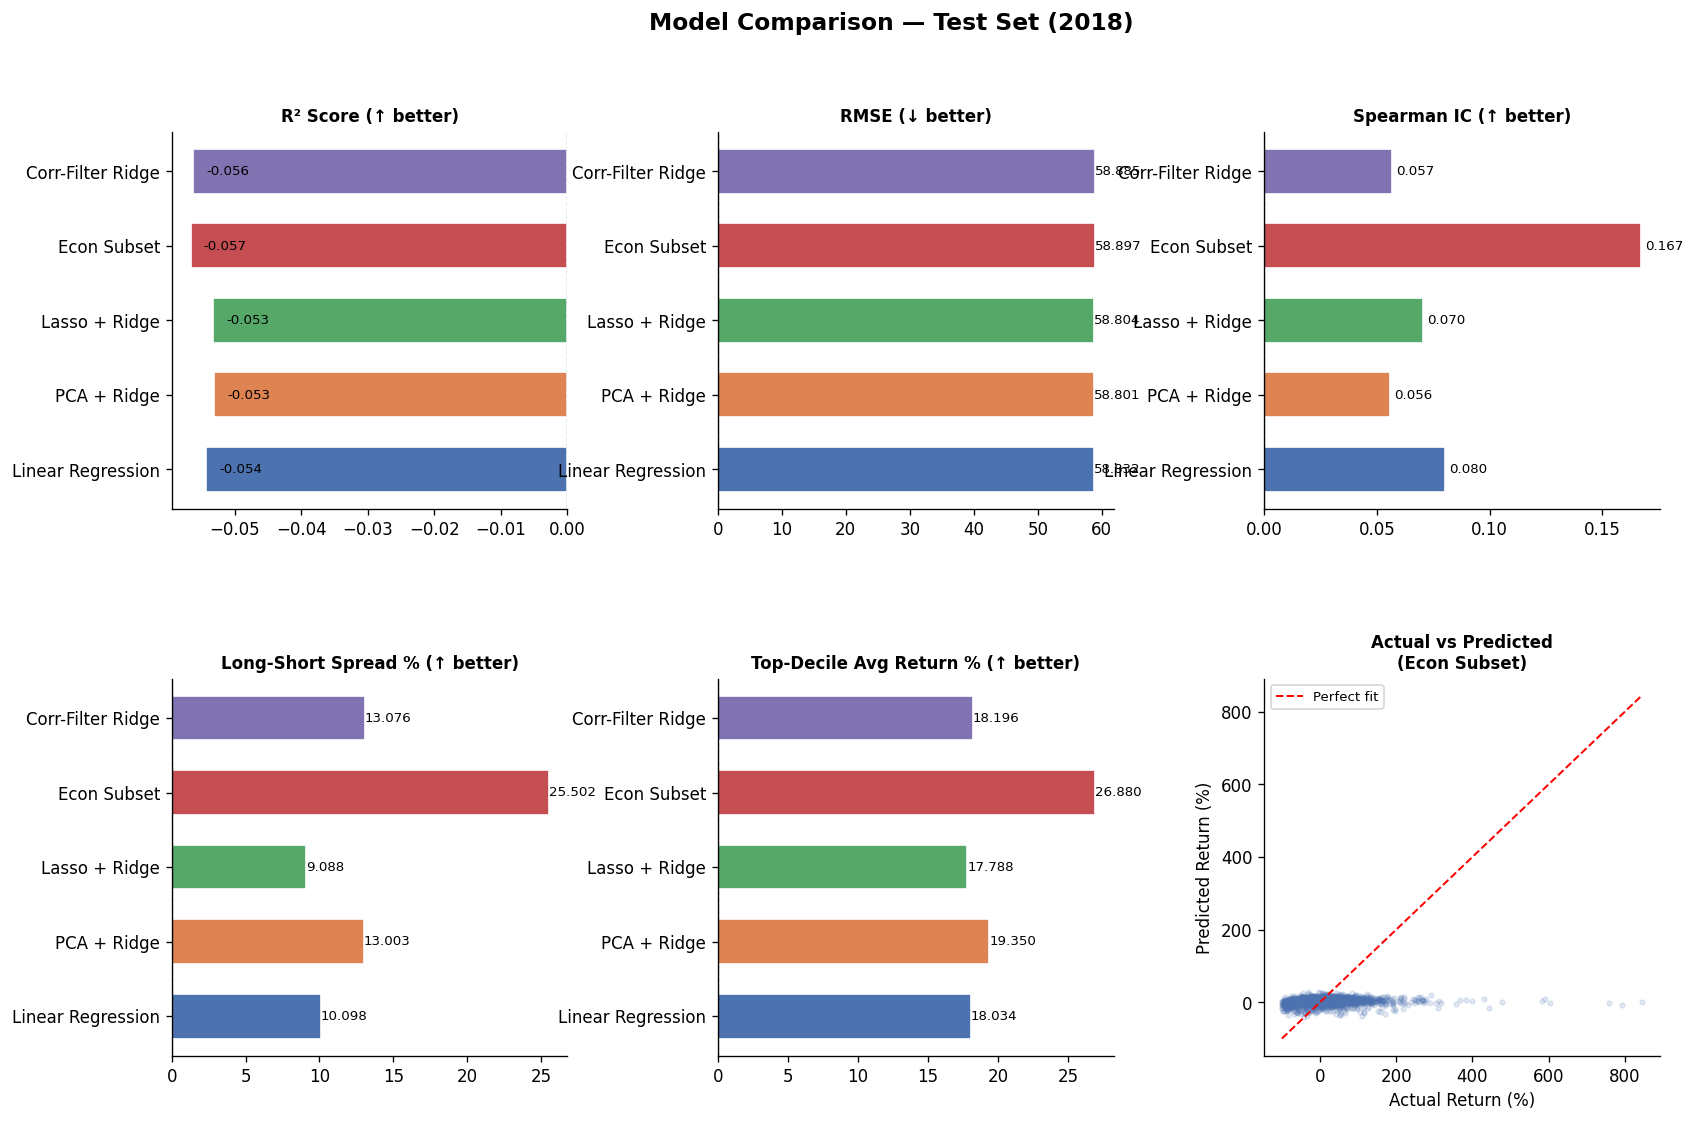


🏆 Best model (Spearman IC): Econ Subset


In [28]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

model_names = list(all_results.keys())
colors      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

metrics = [
    ("R2",          "R² Score (↑ better)"),
    ("RMSE",        "RMSE (↓ better)"),
    ("Spearman_IC", "Spearman IC (↑ better)"),
    ("LS_Spread",   "Long-Short Spread % (↑ better)"),
    ("Top_Decile",  "Top-Decile Avg Return % (↑ better)"),
]

for i, (metric, title) in enumerate(metrics):
    ax   = fig.add_subplot(gs[i // 3, i % 3])
    vals = [all_results[m][metric] for m in model_names]
    bars = ax.barh(model_names, vals, color=colors, edgecolor="white", height=0.6)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.7, linestyle="--")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

# Actual vs Predicted for best model
best_model = summary_df["Spearman_IC"].idxmax()
bp         = test_preds_map[best_model]
ax6        = fig.add_subplot(gs[1, 2])
ax6.scatter(y_test.values, bp, alpha=0.15, s=8, color="#4C72B0")
lims = [min(y_test.min(), bp.min()), max(y_test.max(), bp.max())]
ax6.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")
ax6.set_xlabel("Actual Return (%)")
ax6.set_ylabel("Predicted Return (%)")
ax6.set_title(f"Actual vs Predicted\n({best_model})", fontsize=10, fontweight="bold")
ax6.legend(fontsize=8)

fig.suptitle("Model Comparison — Test Set (2018)", fontsize=14, fontweight="bold")
plt.savefig("03_model_comparison_dashboard.png", bbox_inches="tight")
plt.show()
print(f"\n🏆 Best model (Spearman IC): {best_model}")

---
## Step 17 — Expanding-Window CV Visualisation (Best Ridge)

Expanding-window CV for Ridge (alpha=500.0):
  Train [2014] → Val 2015 | RMSE=60.75  R²=-0.2561  IC=0.0064  L/S=2.18%
  Train [2014, 2015] → Val 2016 | RMSE=56.34  R²=-0.0411  IC=0.0402  L/S=9.64%
  Train [2014, 2015, 2016] → Val 2017 | RMSE=47.43  R²=-0.3482  IC=0.1218  L/S=23.73%


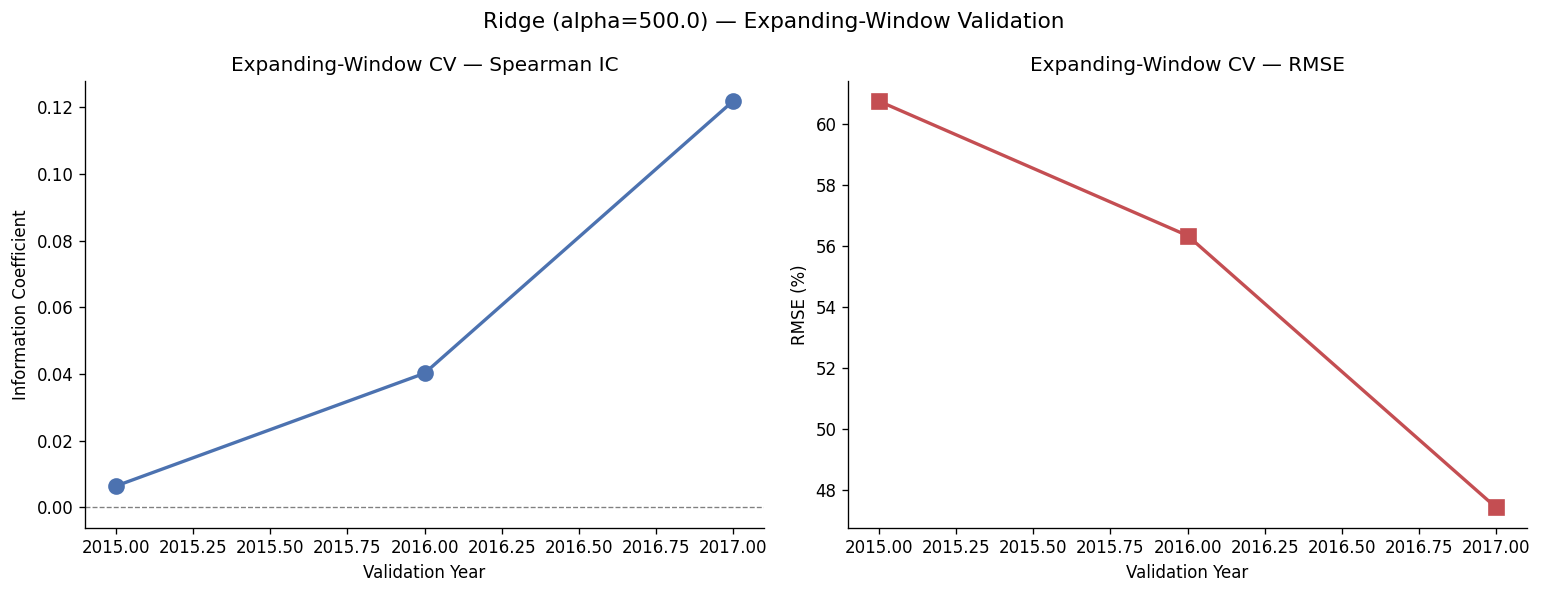

In [29]:
ridge_alpha = float(reg_df[reg_df["Model"] == "Ridge"]["Best_Alpha"].values[0])

pipe_cv = Pipeline([("prep", preprocessor), ("model", Ridge(alpha=ridge_alpha))])
print(f"Expanding-window CV for Ridge (alpha={ridge_alpha}):")
cv_ridge = expanding_cv(pipe_cv, train_df, CV_SPLITS, FINAL_NUM_FEATS, CAT_FEATS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(cv_ridge["Val_Year"], cv_ridge["Spearman_IC"],
             marker="o", color="#4C72B0", linewidth=2, markersize=9)
axes[0].axhline(0, linestyle="--", color="gray", linewidth=0.8)
axes[0].set_title("Expanding-Window CV — Spearman IC")
axes[0].set_xlabel("Validation Year"); axes[0].set_ylabel("Information Coefficient")

axes[1].plot(cv_ridge["Val_Year"], cv_ridge["RMSE"],
             marker="s", color="#C44E52", linewidth=2, markersize=9)
axes[1].set_title("Expanding-Window CV — RMSE")
axes[1].set_xlabel("Validation Year"); axes[1].set_ylabel("RMSE (%)")

plt.suptitle(f"Ridge (alpha={ridge_alpha}) — Expanding-Window Validation", fontsize=13)
plt.tight_layout()
plt.savefig("04_expanding_cv.png", bbox_inches="tight")
plt.show()

---
## Step 18 — Residual Analysis & Final Test Plots

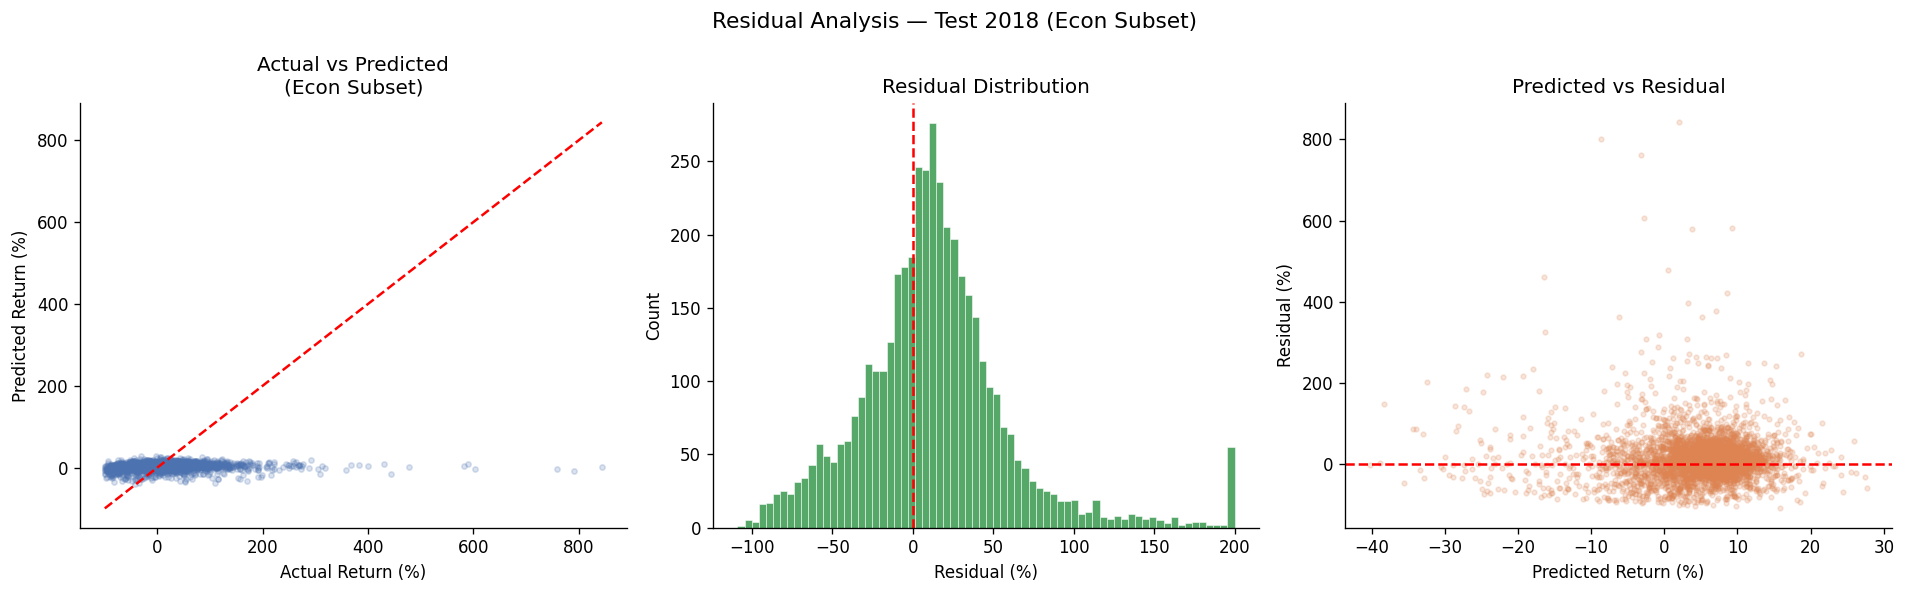


Bias (mean residual) : 14.8504%
Residual std         : 56.9946%


In [30]:
best_test_preds = test_preds_map[best_model]
residuals       = y_test.values - best_test_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y_test.values, best_test_preds, alpha=0.2, s=10, color="#4C72B0")
lims = [min(y_test.min(), best_test_preds.min()), max(y_test.max(), best_test_preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5)
axes[0].set_xlabel("Actual Return (%)"); axes[0].set_ylabel("Predicted Return (%)")
axes[0].set_title(f"Actual vs Predicted\n({best_model})")

# Residual distribution
axes[1].hist(residuals.clip(-150, 200), bins=70,
             color="#55A868", edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual (%)"); axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

# Predicted vs Residual (heteroskedasticity check)
axes[2].scatter(best_test_preds, residuals, alpha=0.2, s=8, color="#DD8452")
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Predicted Return (%)"); axes[2].set_ylabel("Residual (%)")
axes[2].set_title("Predicted vs Residual")

plt.suptitle(f"Residual Analysis — Test 2018 ({best_model})", fontsize=13)
plt.tight_layout()
plt.savefig("05_residual_analysis.png", bbox_inches="tight")
plt.show()

print(f"\nBias (mean residual) : {residuals.mean():.4f}%")
print(f"Residual std         : {residuals.std():.4f}%")

---
## Step 19 — Save Results

In [31]:
out = summary_df.reset_index().rename(columns={"index": "Model"})
out.to_csv("model_results_summary.csv", index=False)
print("✅ Saved: model_results_summary.csv")
out

✅ Saved: model_results_summary.csv


,Model,R2,RMSE,Spearman_IC,LS_Spread,Top_Decile
0,Econ Subset,-0.0566,58.8975,0.1670,25.5018,26.8795
1,Linear Regression,-0.0543,58.8317,0.0801,10.0979,18.0341
2,Lasso + Ridge,-0.0533,58.8036,0.0704,9.0882,17.7883
3,Corr-Filter Ridge,-0.0562,58.8853,0.0567,13.0761,18.1962
4,PCA + Ridge,-0.0532,58.8008,0.0558,13.0033,19.3498


---
## Summary

| Step | Description |
|------|-------------|
| 1 | Load & combine 3 CSV parts (22,031 rows, 207 columns) |
| 2 | Inspect pre-labelled target `Stock_Return` — **no shift required** |
| 3 | Remove leakage: `Class`, `Return_Direction` (derived from target) |
| 4 | **Time-based split**: Train 2014–2017 / Test 2018 |
| 5 | Feature engineering: winsorisation · signed-log · CS z-score · sector-relative · Δ features |
| 6 | Feature selection: variance filter → correlation filter → univariate top-60 |
| 7 | Preprocessing pipeline: imputer + scaler + one-hot |
| 8 | Evaluation helpers: regression metrics + portfolio metrics |
| 9 | **Expanding-window CV** (2014→2015, 2014-15→2016, 2014-16→2017) for tuning |
| 10 | **Exp 1** Baseline Linear Regression |
| 11 | **Exp 2** Ridge / Lasso / Elastic Net (alpha tuned via CV) |
| 12 | **Exp 3** Correlation-filtered features + Ridge |
| 13 | **Exp 4** Lasso-selected features → Ridge |
| 14 | **Exp 5** PCA (95% variance) + Ridge |
| 15 | **Exp 6** Economic feature subset (valuation · profitability · growth · leverage) |
| 16 | Comparison dashboard across 5 metrics on **Test 2018** |
| 17 | Expanding-window CV visualisation |
| 18 | Residual analysis (actual vs predicted, distribution, heteroskedasticity) |
| 19 | Export results to CSV |